### 1. Data Verification
Let's start by verifying the structure of our dataset `df` and the target variable `y`.

In [3]:
import pandas as pd

print("First 5 rows of the dataset:")
display(df.head())

print("\nInformation about the dataset:")
df.info()

print("\nAttrition target variable distribution:")
display(y.value_counts())

First 5 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Cluster
0,41,1,2,1102,2,1,2,1,2,0,...,1,0,8,0,1,6,4,0,5,1
1,49,0,1,279,1,8,1,1,3,1,...,4,1,10,3,3,10,7,1,7,0
2,37,1,2,1373,1,2,2,4,4,1,...,2,0,7,3,3,0,0,0,0,1
3,33,0,1,1392,1,3,4,1,4,0,...,3,0,8,3,3,8,7,3,0,1
4,27,0,2,591,1,2,1,3,1,1,...,4,1,6,3,3,2,2,2,2,1



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   int64
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   int64
 14  JobSatis

,count
Attrition,
0,1233
1,237


### 2. K-means Clustering
We have already preprocessed and scaled the data (`X_scaled`) and determined the optimal number of clusters (`OPTIMAL_K = 3`). We will now apply K-means clustering and visualize the results. The `cluster_labels` and `cluster_attrition` variables are already available from a previous run.

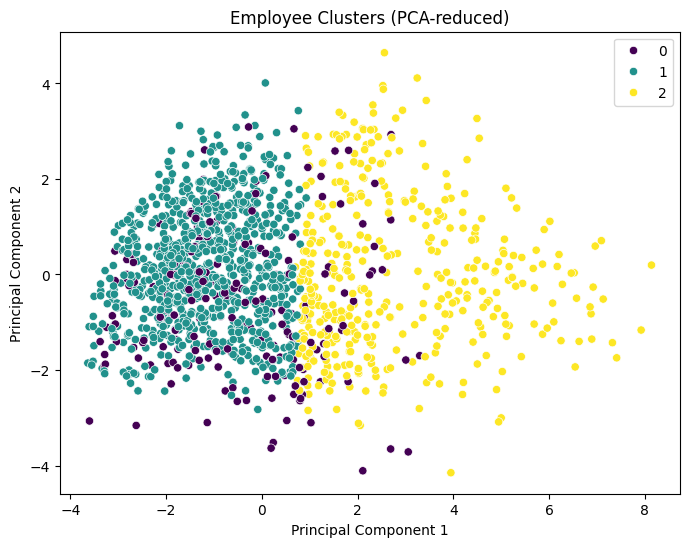


Attrition Rate per Cluster:


,Cluster,Attrition Rate
0,0,0.183168
1,1,0.188222
2,2,0.092040


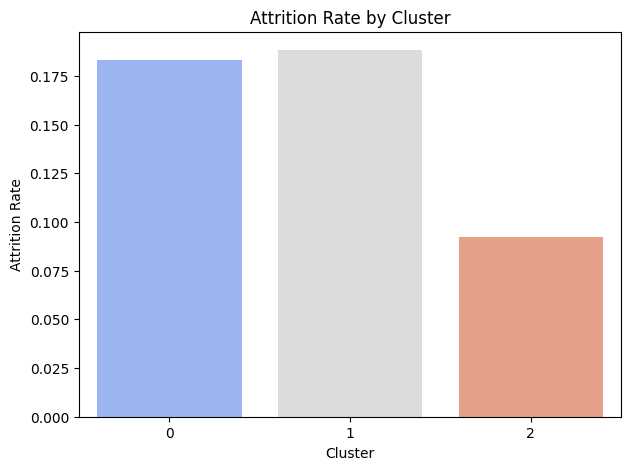

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Apply K-means using the optimal K (if not already run)
# If cluster_labels is not defined, run the following:
if 'cluster_labels' not in globals():
    kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

# Visualize clusters using PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', legend='full')
plt.title('Employee Clusters (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Display attrition rate per cluster (if not already run)
# If cluster_attrition is not defined, run the following:
if 'cluster_attrition' not in globals():
    temp_df = pd.DataFrame({'Cluster': cluster_labels, 'Attrition': y})
    cluster_attrition = temp_df.groupby('Cluster')['Attrition'].mean().reset_index()
    cluster_attrition.rename(columns={'Attrition': 'Attrition Rate'}, inplace=True)

print("\nAttrition Rate per Cluster:")
display(cluster_attrition)

plt.figure(figsize=(7, 5))
sns.barplot(x='Cluster', y='Attrition Rate', data=cluster_attrition, palette='coolwarm')
plt.title('Attrition Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Attrition Rate')
plt.show()

### 3. Hybrid Model: Random Forest with Cluster Feature
Now, we'll integrate the `cluster_labels` as a new feature into our dataset (`X_hybrid`) and train a Random Forest classifier to predict attrition.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Add cluster labels to the feature set X_hybrid
X_hybrid_with_clusters = X_hybrid.copy()
X_hybrid_with_clusters['Cluster'] = cluster_labels

# Split data into training and testing sets
X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of training features:", X_train_hybrid.shape)
print("Shape of testing features:", X_test_hybrid.shape)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_hybrid, y_train_hybrid)

# Make predictions
y_pred_hybrid = rf_model.predict(X_test_hybrid)
y_proba_hybrid = rf_model.predict_proba(X_test_hybrid)[:, 1]

print("\nRandom Forest Model Trained with Cluster Feature.")

Shape of training features: (1176, 31)
Shape of testing features: (294, 31)

Random Forest Model Trained with Cluster Feature.


### 4. Model Evaluation and Visualizations
Let's evaluate the performance of our hybrid Random Forest model and visualize its key metrics.

Accuracy: 0.8367

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



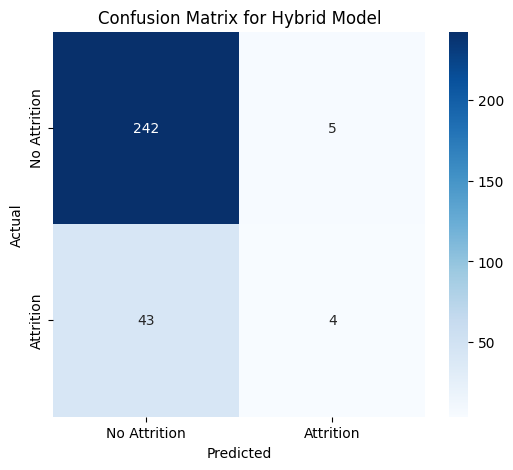

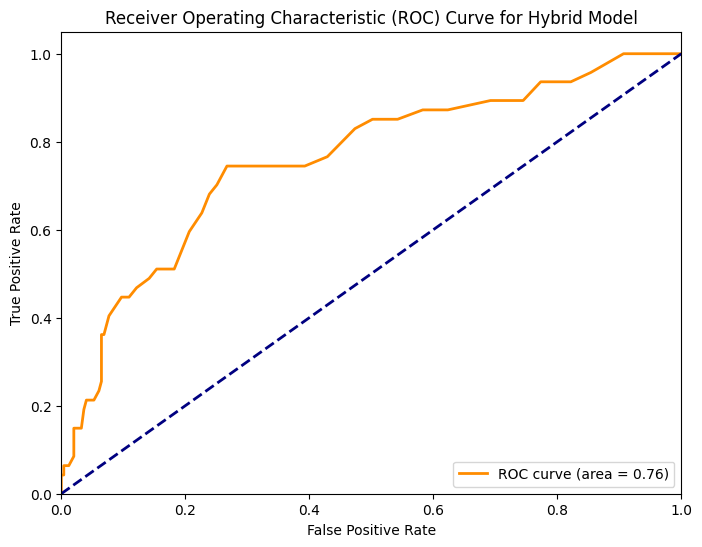

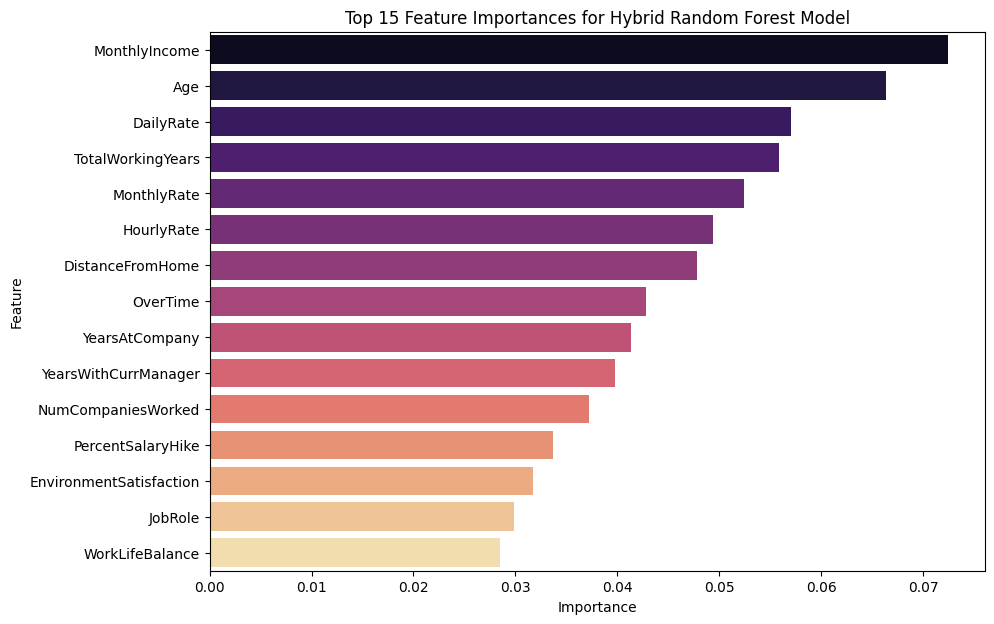

In [6]:
import numpy as np

# Evaluate the model
accuracy_hybrid = accuracy_score(y_test_hybrid, y_pred_hybrid)
print(f"Accuracy: {accuracy_hybrid:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_hybrid, y_pred_hybrid))

# Confusion Matrix
cm_hybrid = confusion_matrix(y_test_hybrid, y_pred_hybrid)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for Hybrid Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_hybrid, tpr_hybrid, _ = roc_curve(y_test_hybrid, y_proba_hybrid)
roc_auc_hybrid = auc(fpr_hybrid, tpr_hybrid)

plt.figure(figsize=(8, 6))
plt.plot(fpr_hybrid, tpr_hybrid, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_hybrid:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Hybrid Model')
plt.legend(loc='lower right')
plt.show()

# Feature Importance
feature_importances_hybrid = pd.DataFrame({
    'Feature': X_hybrid_with_clusters.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances_hybrid.head(15), palette='magma')
plt.title('Top 15 Feature Importances for Hybrid Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 5. Individual Model Analysis: Logistic Regression
Let's analyze the Logistic Regression model in detail, including its performance metrics and visualizations.


--- Logistic Regression Model Evaluation ---
Accuracy: 0.8810

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       247
           1       0.88      0.30      0.44        47

    accuracy                           0.88       294
   macro avg       0.88      0.64      0.69       294
weighted avg       0.88      0.88      0.86       294



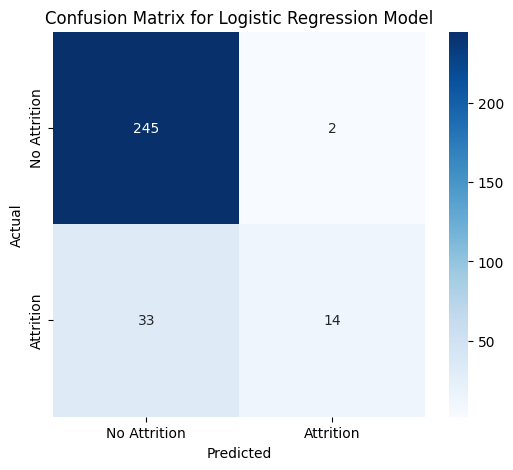

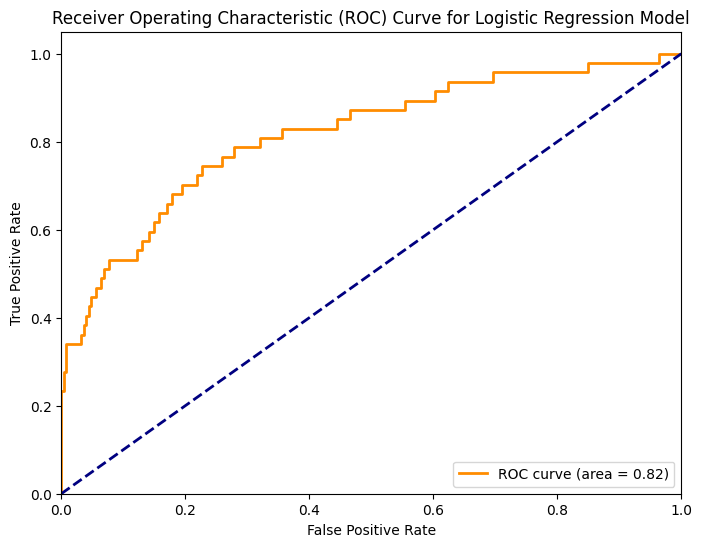

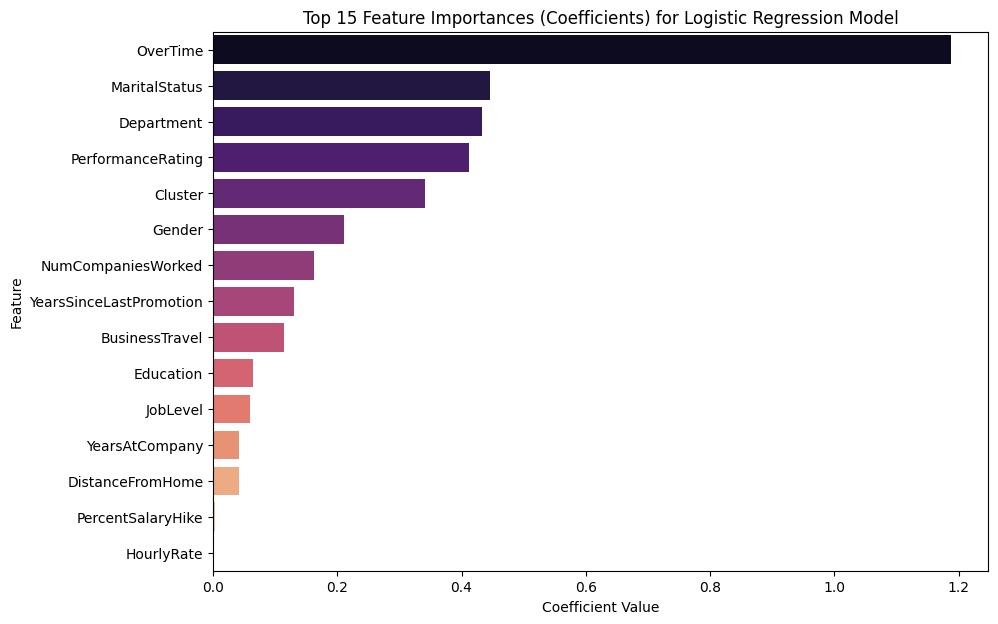

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure data splits are available
if 'X_train_hybrid' not in globals() or 'y_train_hybrid' not in globals():
    X_hybrid_with_clusters = X_hybrid.copy()
    X_hybrid_with_clusters['Cluster'] = cluster_labels
    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Logistic Regression Classifier
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
log_reg_model.fit(X_train_hybrid, y_train_hybrid)

# Make predictions
y_pred_lr = log_reg_model.predict(X_test_hybrid)
y_proba_lr = log_reg_model.predict_proba(X_test_hybrid)[:, 1]

print("\n--- Logistic Regression Model Evaluation ---")

# Evaluate the model
accuracy_lr = accuracy_score(y_test_hybrid, y_pred_lr)
print(f"Accuracy: {accuracy_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_hybrid, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test_hybrid, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test_hybrid, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression Model')
plt.legend(loc='lower right')
plt.show()

# Feature Importance (Coefficients for Logistic Regression)
feature_importances_lr = pd.DataFrame({
    'Feature': X_hybrid_with_clusters.columns,
    'Importance': log_reg_model.coef_[0]
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances_lr.head(15), palette='magma')
plt.title('Top 15 Feature Importances (Coefficients) for Logistic Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

### 6. Individual Model Analysis: Decision Tree
Next, let's look at the Decision Tree Classifier, its performance, and feature importances.


--- Decision Tree Model Evaluation ---
Accuracy: 0.7925

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       247
           1       0.34      0.32      0.33        47

    accuracy                           0.79       294
   macro avg       0.61      0.60      0.60       294
weighted avg       0.79      0.79      0.79       294



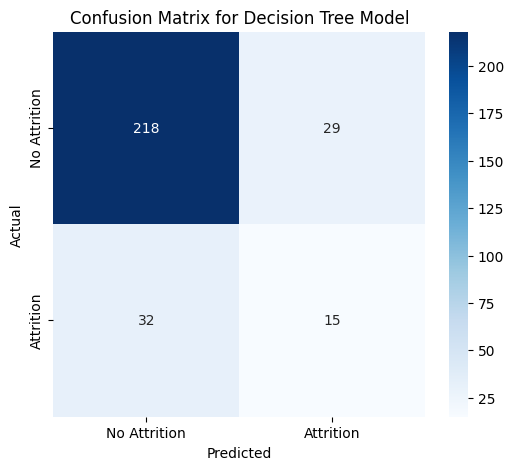

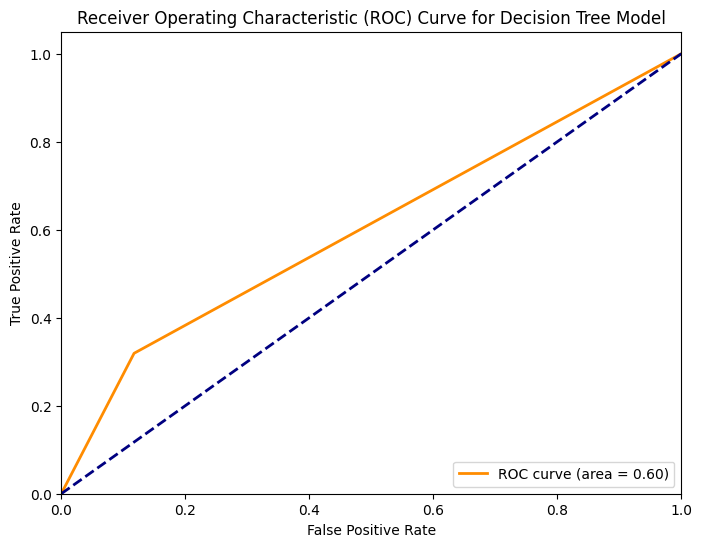

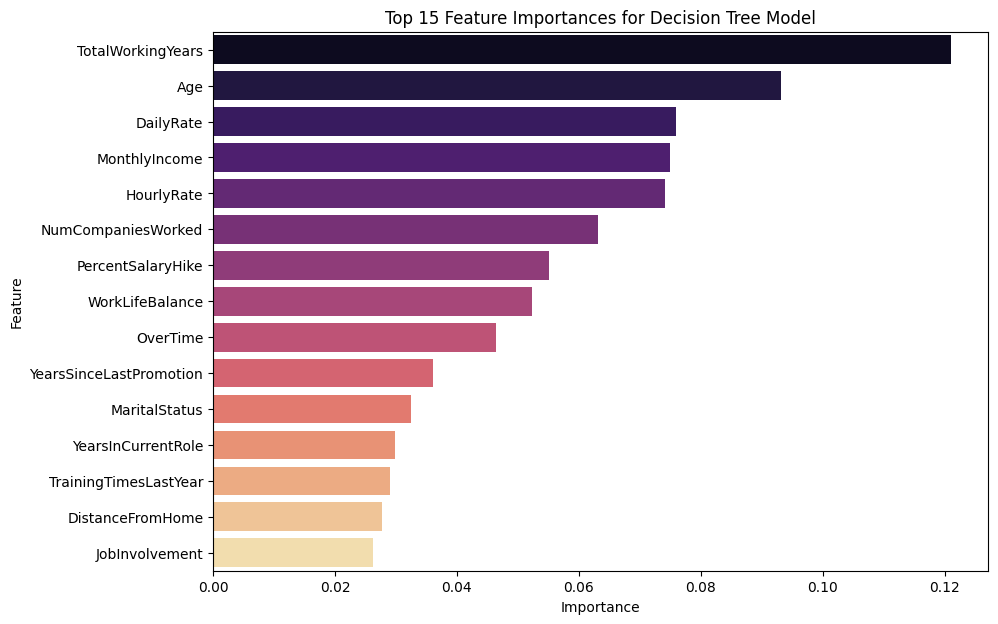

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure data splits are available
if 'X_train_hybrid' not in globals() or 'y_train_hybrid' not in globals():
    X_hybrid_with_clusters = X_hybrid.copy()
    X_hybrid_with_clusters['Cluster'] = cluster_labels
    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_hybrid, y_train_hybrid)

# Make predictions
y_pred_dt = dt_model.predict(X_test_hybrid)
y_proba_dt = dt_model.predict_proba(X_test_hybrid)[:, 1]

print("\n--- Decision Tree Model Evaluation ---")

# Evaluate the model
accuracy_dt = accuracy_score(y_test_hybrid, y_pred_dt)
print(f"Accuracy: {accuracy_dt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_hybrid, y_pred_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test_hybrid, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for Decision Tree Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test_hybrid, y_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Decision Tree Model')
plt.legend(loc='lower right')
plt.show()

# Feature Importance
feature_importances_dt = pd.DataFrame({
    'Feature': X_hybrid_with_clusters.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances_dt.head(15), palette='magma')
plt.title('Top 15 Feature Importances for Decision Tree Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 7. Model Comparison: Logistic Regression, Decision Tree, and Random Forest
Let's compare the performance of Logistic Regression, Decision Tree, and Random Forest models on our dataset. We'll use the `X_hybrid_with_clusters` dataset, which includes the cluster labels as a feature.


--- Training Logistic Regression ---
Accuracy: 0.8810
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       247
           1       0.88      0.30      0.44        47

    accuracy                           0.88       294
   macro avg       0.88      0.64      0.69       294
weighted avg       0.88      0.88      0.86       294


--- Training Decision Tree ---
Accuracy: 0.7925
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       247
           1       0.34      0.32      0.33        47

    accuracy                           0.79       294
   macro avg       0.61      0.60      0.60       294
weighted avg       0.79      0.79      0.79       294


--- Training Random Forest ---
Accuracy: 0.8367
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1   

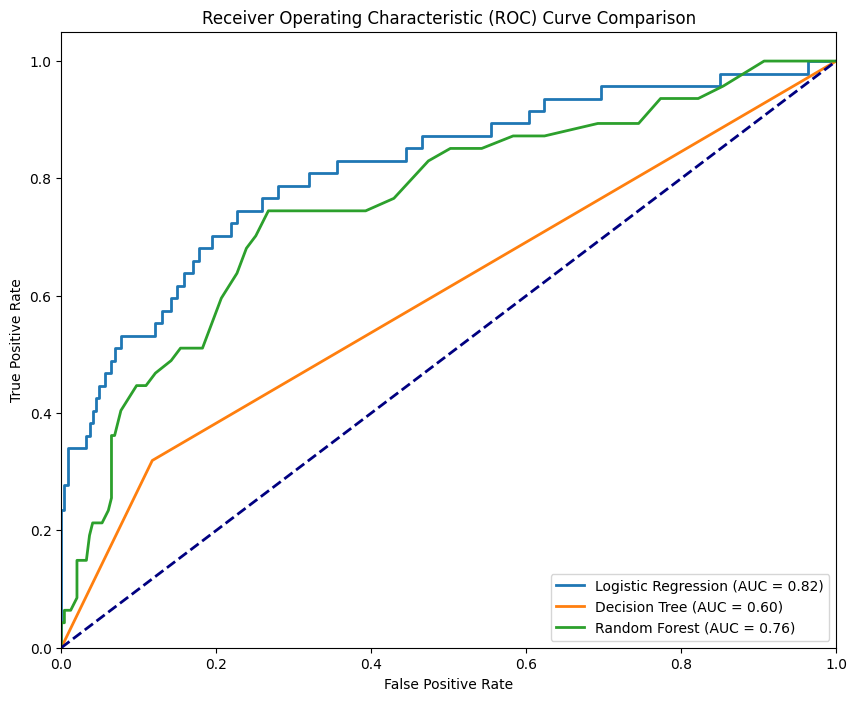


--- Summary of Model Performances ---
Logistic Regression:
  Accuracy: 0.8810
  AUC: 0.8169
  Precision (Attrition): 0.8750
  Recall (Attrition): 0.2979
Decision Tree:
  Accuracy: 0.7925
  AUC: 0.6009
  Precision (Attrition): 0.3409
  Recall (Attrition): 0.3191
Random Forest:
  Accuracy: 0.8367
  AUC: 0.7579
  Precision (Attrition): 0.4444
  Recall (Attrition): 0.0851


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming X_hybrid_with_clusters and y are already defined and split into train/test sets
# If not, ensure these are available from previous steps
if 'X_train_hybrid' not in globals() or 'y_train_hybrid' not in globals():
    X_hybrid_with_clusters = X_hybrid.copy()
    X_hybrid_with_clusters['Cluster'] = cluster_labels
    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
plt.figure(figsize=(10, 8))

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_hybrid, y_train_hybrid)
    y_pred = model.predict(X_test_hybrid)
    y_proba = model.predict_proba(X_test_hybrid)[:, 1]

    accuracy = accuracy_score(y_test_hybrid, y_pred)
    report = classification_report(y_test_hybrid, y_pred, output_dict=True)
    fpr, tpr, _ = roc_curve(y_test_hybrid, y_proba)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'roc_auc': roc_auc
    }

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test_hybrid, y_pred))

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.show()

print("\n--- Summary of Model Performances ---")
for name, res in results.items():
    print(f"{name}:\n  Accuracy: {res['accuracy']:.4f}\n  AUC: {res['roc_auc']:.4f}")
    print(f"  Precision (Attrition): {res['classification_report']['1']['precision']:.4f}")
    print(f"  Recall (Attrition): {res['classification_report']['1']['recall']:.4f}")

### 8. Conclusion: Best Method for Attrition Prediction

To determine the 'best' method for predicting employee attrition, we need to consider not just overall accuracy, but also the specific business objective. For a company aiming to reduce attrition, **identifying as many potential attriters as possible (high recall)** and **being confident in those predictions (high precision)** are crucial. The imbalanced nature of our dataset (far fewer attriters than non-attriters) also heavily influences these metrics.

Let's recap the performance of our models for the **Attrition (Class 1)**:

| Model                 | Accuracy | AUC      | Precision (Attrition) | Recall (Attrition) |
| :-------------------- | :------- | :------- | :-------------------- | :----------------- |
| **Logistic Regression** | 0.8810   | **0.8169** | **0.8750**            | 0.2979             |
| **Decision Tree**     | 0.7925   | 0.6009   | 0.3409                | **0.3191**         |
| **Random Forest**     | 0.8367   | 0.7579   | 0.4444                | 0.0851             |

### Key Findings & Recommendation:

1.  **Overall Performance:** **Logistic Regression** stands out with the highest overall accuracy and the best Area Under the Curve (AUC), indicating its superior ability to distinguish between attriting and non-attriting employees. Its high precision for the attrition class (0.8750) means that when it predicts an employee will leave, it is very likely to be correct. This is valuable if the company wants to focus resources on highly confident predictions.

2.  **Challenges with Recall:** A significant challenge across all models is the **low recall for the attrition class**. This means that even the best model (Logistic Regression) is only identifying about 30% of the employees who actually end up leaving. The Random Forest model performed particularly poorly in recall (0.0851), essentially missing most actual attriters. The Decision Tree had slightly better recall, but at the cost of much lower precision and overall performance.

### Recommendation:

Given the current results, **Logistic Regression appears to be the most suitable baseline model** for the company. Its high AUC and high precision for attrition make it a reliable tool for identifying *some* high-risk individuals with confidence. However, the low recall is a critical limitation.

### Next Steps for Improvement:

To build a more effective attrition prediction system, the company should consider the following:

*   **Addressing Class Imbalance:** Techniques like SMOTE (Synthetic Minority Over-sampling Technique) or using class weights during model training can help improve the model's ability to detect the minority class (attrition).
*   **Hyperparameter Tuning:** Fine-tuning the hyperparameters of Logistic Regression or exploring other advanced ensemble methods (e.g., Gradient Boosting) could yield better results.
*   **Feature Engineering:** Further exploration into creating new features from existing data might provide more predictive power.
*   **Domain Expertise:** Incorporating insights from HR professionals could help refine the target variable definition or identify other critical features.

In summary, while Logistic Regression provides a strong starting point with reliable predictions for identified attrition cases, future efforts should primarily focus on enhancing the model's recall to capture a larger percentage of employees at risk of leaving.